# Develop quick stuff

For temporary/quick stuff to be developed

In [1]:
import numpy as np

In [ ]:
C, p_minus_1, k, q_tilde = 2, 8, 22, 4


unorganized_data = np.random.normal(size=(C, p_minus_1, k, q_tilde))

idx_limit_to_move = 

In [184]:
import torch
import time
import pandas as pd

batch_sizes_from = 16
batch_sizes_to_test = range(batch_sizes_from, 512)
performance_report = []
N = 500

time_begin = time.time()
mask_ok = lambda mask : (mask.sum(axis=-1) <= wished_upper_bound_conf_preds).all() and not mask[~mask_conf_preds].any()

for b_idx ,B in enumerate(batch_sizes_to_test):
    if (b_idx + 1) % 32 == 0:
        mean_time_until_now = (time.time() - time_begin)/(b_idx + 1)
        batches_to_go = len(batch_sizes_to_test)  - b_idx
        print("Starting batch size", B, "Expected time left:", mean_time_until_now * batches_to_go, "(s)")
    mask_conf_preds = torch.randint(0,2, torch.Size([B,N]), dtype=torch.bool)
    count_conf_preds = mask_conf_preds.sum(dim=-1)

    wished_upper_bound_conf_preds = round(0.05 * N)
    count_conf_to_flip_to_false = torch.maximum(count_conf_preds - wished_upper_bound_conf_preds, torch.tensor(0))
    keep_counts = torch.clamp(count_conf_preds, max=wished_upper_bound_conf_preds)

    for _ in range(50):
        mask_conf_preds_readable = mask_conf_preds.clone()
        begin_readable = time.time()
        scores = torch.where(mask_conf_preds_readable, torch.rand_like(mask_conf_preds, dtype=torch.float), -float('inf'))
        for b in range(mask_conf_preds_readable.size(0)):
            mask_conf_preds_readable[b, scores[b].topk(count_conf_to_flip_to_false[b]).indices] = False
        end_readable = time.time()

        mask_conf_preds_vec = mask_conf_preds.clone()

        begin_vec = time.time()
        # let conf_max = count_conf_preds.max()
        rand_perms = torch.rand(mask_conf_preds_vec.size(0), #[B, conf_max]
                                count_conf_preds.max(), 
                                device=count_conf_preds.device).argsort(dim=1)
        # set to nan where permutation too high according to the amount of conf preds in that batch dimension
        rand_perms = torch.where(rand_perms < count_conf_preds.unsqueeze(-1), #[B, conf_max]
                                    rand_perms, 
                                    torch.tensor(torch.nan, device=count_conf_preds.device)) 

        help_add_to_get_obj_idx = torch.cat([torch.tensor([0]), count_conf_preds[:-1].cumsum(dim=0)]).unsqueeze(-1) # [B, 1]

        rand_perms_with_obj_idx = rand_perms + help_add_to_get_obj_idx #[B, conf_max]
        # contains the relative indices of the subset of the mask where is true
        rand_perms_with_obj_idx = rand_perms_with_obj_idx[~rand_perms_with_obj_idx.isnan()].long() #[n_conf]

        # Get now the ":count_conf_to_flip_to_false" slices by getting the indices of rand_perms_with_obj_idx
        # which would correspond to getting the first count_conf_to_flip_to_false per batch of the made permutation
        # let to_flip_max = count_conf_to_flip_to_false.max()
        idx_to_choose_from_randperm = torch.arange(count_conf_to_flip_to_false.max()).unsqueeze(0).repeat(mask_conf_preds_vec.size(0), 1) # [B, to_flip_max]
        # same nan setting logic as before
        idx_to_choose_from_randperm = torch.where( #[B, to_flip_max]
            idx_to_choose_from_randperm < count_conf_to_flip_to_false.unsqueeze(-1), 
            idx_to_choose_from_randperm, 
            torch.tensor(torch.nan, device=count_conf_preds.device)
        )
        idx_to_choose_from_randperm_obj = idx_to_choose_from_randperm + help_add_to_get_obj_idx #[B, to_flip_max]
        idx_to_choose_from_randperm_obj = idx_to_choose_from_randperm_obj[~idx_to_choose_from_randperm_obj.isnan()].long() #[n_flip]

        idxs_among_conf_to_flip_to_false = rand_perms_with_obj_idx[idx_to_choose_from_randperm_obj] # [n_flip]

        shape_before = mask_conf_preds_vec.shape
        flattened_idxs_to_flip_to_false = torch.arange(mask_conf_preds_vec.numel()).reshape(shape_before)[mask_conf_preds_vec][idxs_among_conf_to_flip_to_false]
        mask_conf_preds_vec=mask_conf_preds_vec.flatten()
        mask_conf_preds_vec[flattened_idxs_to_flip_to_false] = False
        mask_conf_preds_vec = mask_conf_preds_vec.reshape(shape_before)

        end_vec = time.time()

        mask_conf_pred_topk = mask_conf_preds.clone()

        begin_vec_topk = time.time()

        k_max = int(keep_counts.max().item())
        scores = torch.where(mask_conf_pred_topk, torch.rand_like(mask_conf_pred_topk, dtype=torch.float), -float('inf'))
        # Get up to k_max candidates per row
        _, topk_idx = scores.topk(k_max, dim=-1)  # [B, k_max]

        # Build per-row masks for how many to keep (some rows keep < k_max)
        idx_range = torch.arange(k_max, device=mask_conf_pred_topk.device)  # [k_max]
        # keep_mask[b, j] = j < keep_counts[b]
        keep_mask = idx_range.unsqueeze(0) < keep_counts.unsqueeze(1)   # [B, k_max]

        # Initialize new mask all False
        new_mask = torch.zeros_like(mask_conf_pred_topk, dtype=torch.bool)

        # Apply keep_mask via advanced indexing
        # For rows where keep_counts[b] == 0, keep_mask[b] is all False, so nothing is set
        batch_idx = torch.arange(B, device=mask_conf_pred_topk.device).unsqueeze(1).expand_as(topk_idx)
        # Filter only positions to keep
        valid = keep_mask
        new_mask[batch_idx[valid], topk_idx[valid]] = True

        mask_conf_pred_topk = new_mask
        end_vec_top_k = time.time()

        
        assert mask_ok(mask_conf_preds_vec) and mask_ok(mask_conf_preds_readable) and mask_ok(mask_conf_pred_topk)

        performance_report.append(
            pd.Series({"Readable" : end_readable - begin_readable, 
                       "Vectorized" : end_vec - begin_vec, 
                       "TopK" : end_vec_top_k - begin_vec_topk, 
                       "B" : b})
            )

Starting batch size 47 Expected time left: 113.16694099456072 (s)
Starting batch size 79 Expected time left: 142.29239136353135 (s)
Starting batch size 111 Expected time left: 165.53910266111293 (s)
Starting batch size 143 Expected time left: 183.8737615942955 (s)
Starting batch size 175 Expected time left: 194.41301341503856 (s)
Starting batch size 207 Expected time left: 193.03020689015585 (s)
Starting batch size 239 Expected time left: 186.88740967959166 (s)
Starting batch size 271 Expected time left: 176.03030692320317 (s)
Starting batch size 303 Expected time left: 162.5564979902572 (s)
Starting batch size 335 Expected time left: 146.21617299467326 (s)
Starting batch size 367 Expected time left: 126.8887885016474 (s)
Starting batch size 399 Expected time left: 104.32824454704921 (s)
Starting batch size 431 Expected time left: 78.88026673174822 (s)
Starting batch size 463 Expected time left: 50.12194915488363 (s)
Starting batch size 495 Expected time left: 18.210727614164355 (s)


In [195]:
topk_idx.shape, 511*25

(torch.Size([511, 25]), 12775)

In [194]:
topk_idx[valid].shape

torch.Size([12775])

In [185]:
performance_report = pd.DataFrame(performance_report)
grouped_performance_report = performance_report.groupby(by="B").mean()

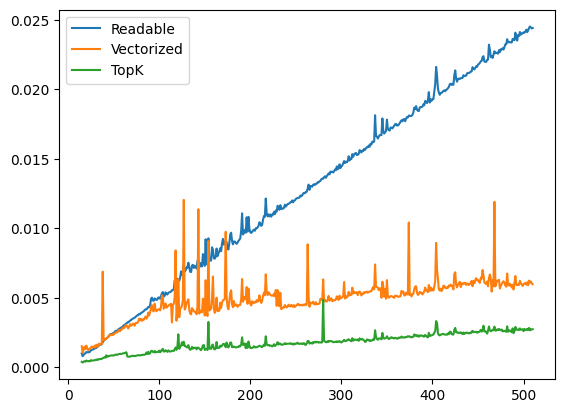

In [186]:
import matplotlib.pyplot as plt

for method_name in ["Readable", "Vectorized", "TopK"]:
    plt.plot(grouped_performance_report.index, grouped_performance_report[method_name], label=method_name)

plt.legend()
plt.show()